In [1]:
# General purpose
import numpy as np
import pandas as pd
from glob import glob

# Metrics
from cellpose_omni.metrics import average_precision

import matplotlib.pyplot as plt
import seaborn as sns

from skimage import io

In [2]:
mtg_gt = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/MTG/Selected/GT/*'))
mtg_segmented = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/MTG/Selected/FMSeg/*'))

mtg_gt = [io.imread(mtg) for mtg in mtg_gt]
mtg_segmented = [io.imread(mtg) for mtg in mtg_segmented]

qoxB_gt = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/QoxB/Selected/GT/*'))
qoxB_segmented = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/QoxB/Selected/FMSeg/*'))

qoxB_gt = [io.imread(qoxB) for qoxB in qoxB_gt]
qoxB_segmented = [io.imread(qoxB) for qoxB in qoxB_segmented]



In [3]:
thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]

JI_mtg, tp, fp, fn = average_precision(mtg_gt,mtg_segmented,thresholds)
f1_mtg = 2*tp/(2*tp+fn+fp)

JI_qoxB, tp, fp, fn = average_precision(qoxB_gt,qoxB_segmented,thresholds)
f1_qoxB = 2*tp/(2*tp+fn+fp)


In [11]:
f1s = [f1_mtg,f1_qoxB]

names = ['MitoTrackerGreen','QoxB_sfGFP']#

dfs = []

for i in range(len(qoxB_gt)):

    for f,n in zip(f1s,names):
            
        df = pd.DataFrame()

        df.insert(0,'F1',f[i])
        df.insert(0,'Threshold',thresholds)
        df.insert(0,'Dye',n)
        df.insert(3,'Image',i)

        dfs.append(df)

full_df = pd.concat(dfs)
full_df.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS4.csv')

In [29]:
full_df = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS4.csv')
thresh_08 = full_df[full_df['Threshold'] == 0.8]

/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_4792/734329825.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_4792/734329825.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(labels=ax[0].get_xticklabels(),fontsize=12)
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_4792/734329825.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_4792/734329825.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

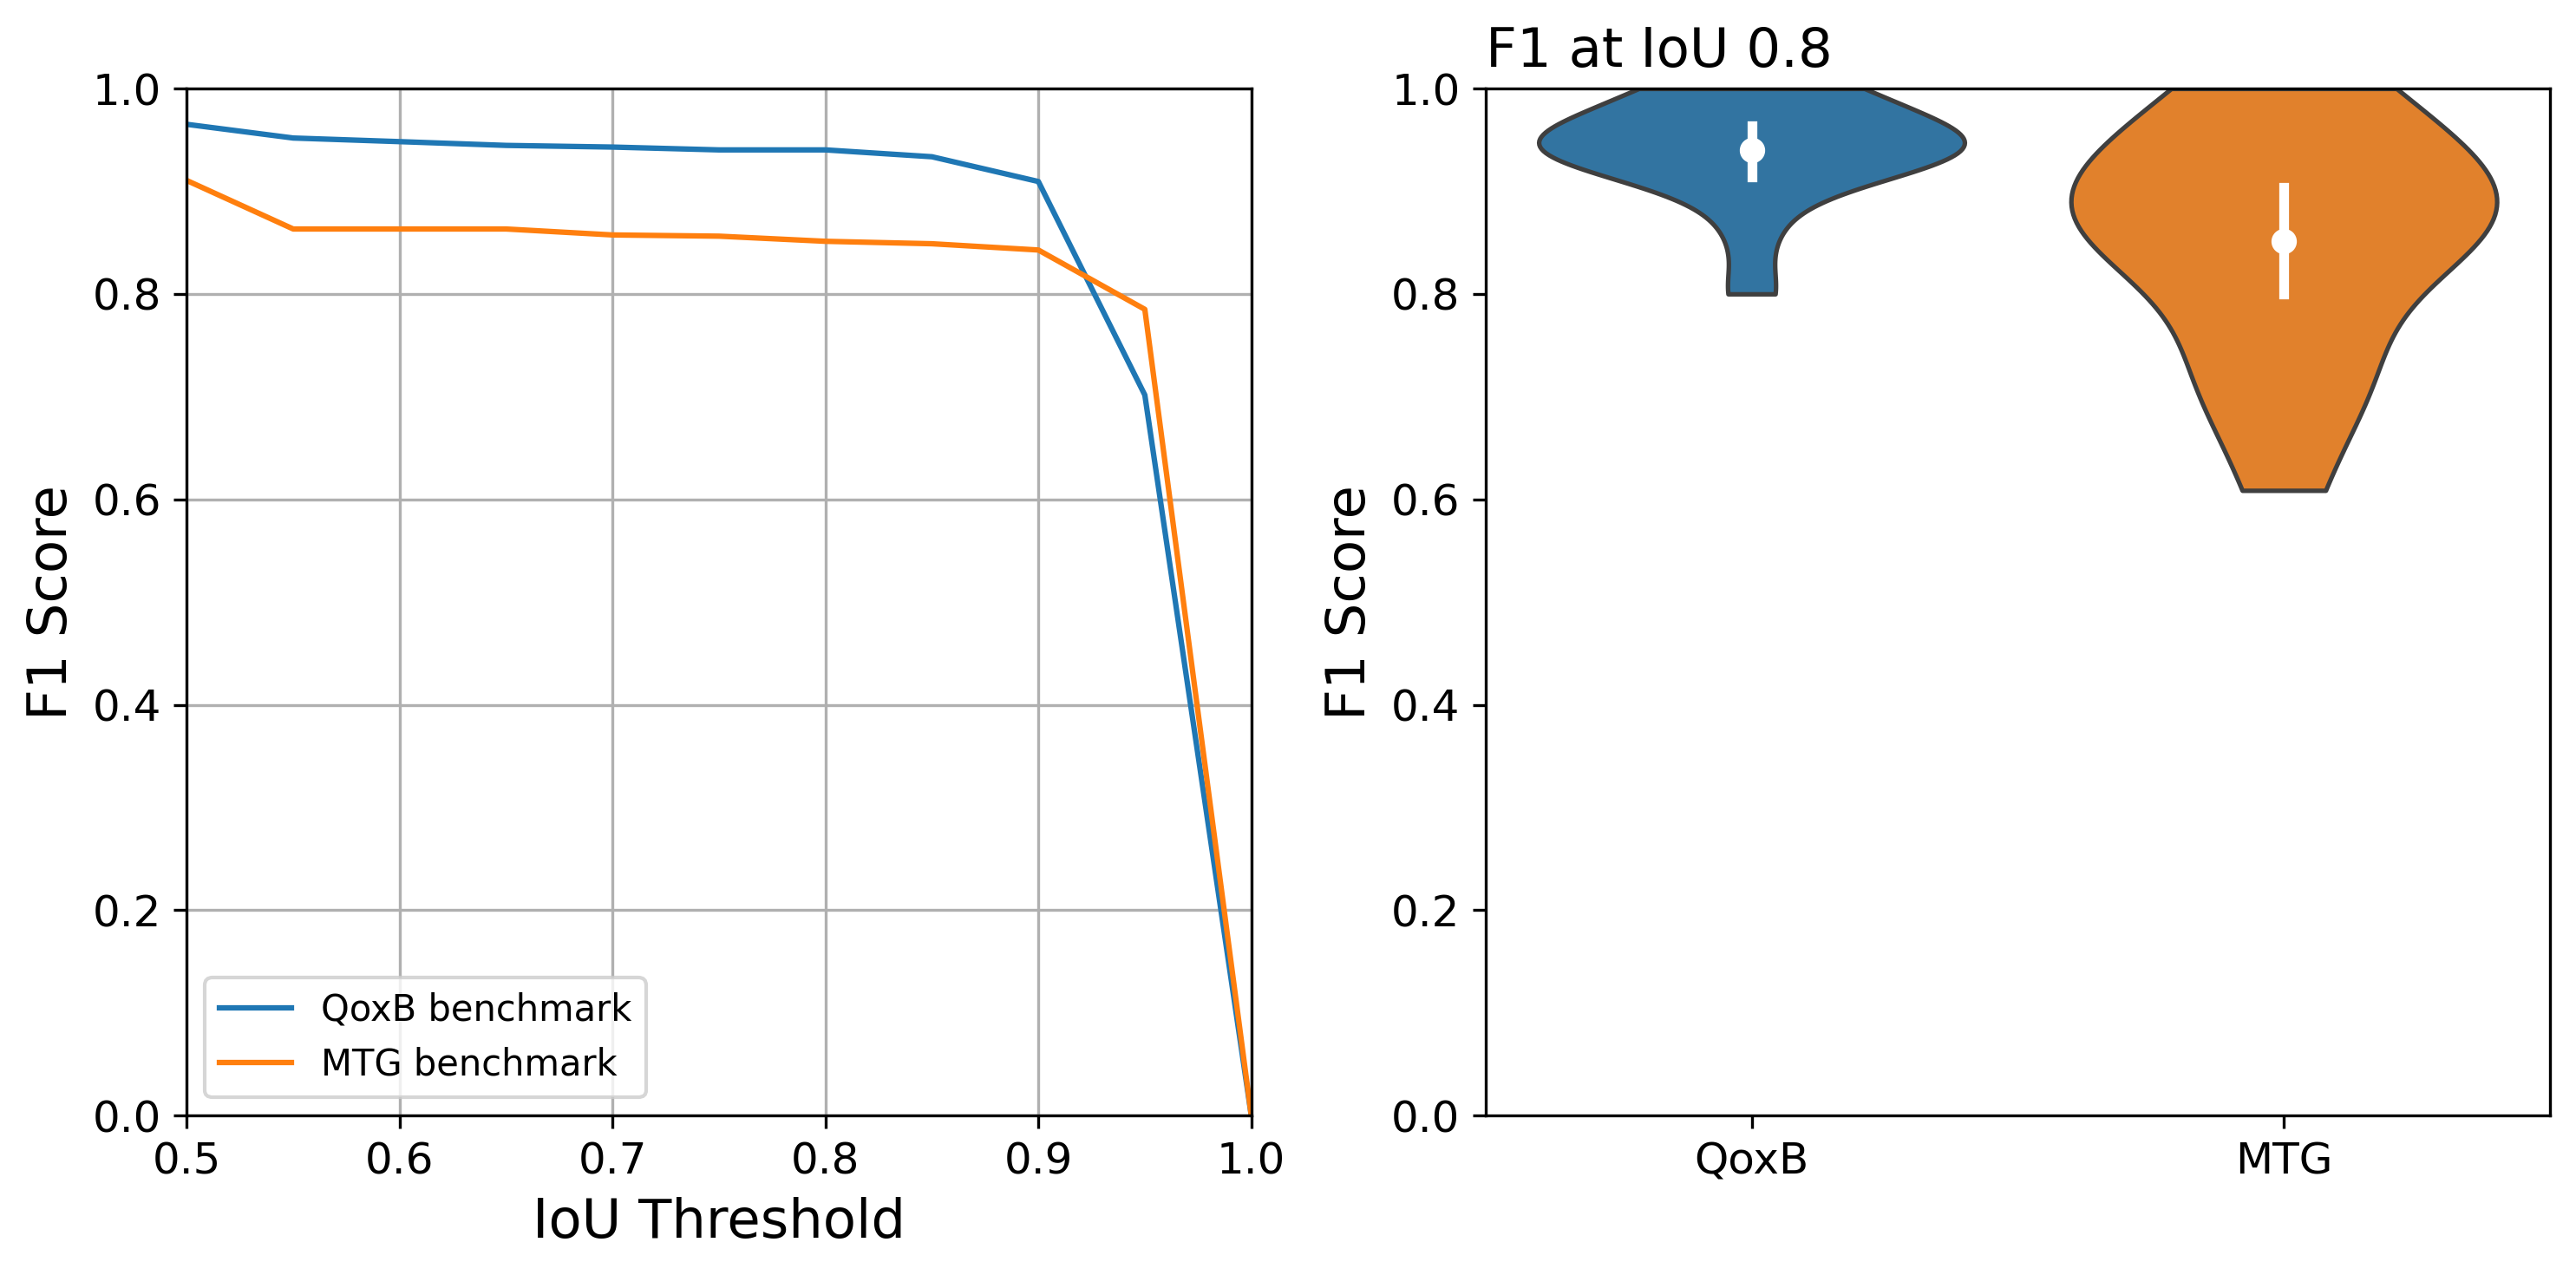

In [30]:
fig,ax = plt.subplots(dpi=300, figsize=(10,5), ncols=2)

sns.lineplot(data=full_df,x='Threshold',y='F1',hue='Dye',hue_order=['QoxB_sfGFP','MitoTrackerGreen'],errorbar=None,ax=ax[0])
ax[0].set_ylim(0,1)
ax[0].grid(visible=True,axis='both')
ax[0].set_ylabel('F1 Score',fontsize=15)
ax[0].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
ax[0].set_xlabel('IoU Threshold',fontsize=15)
ax[0].set_xlim(0.5,1)
ax[0].set_xticklabels(labels=ax[0].get_xticklabels(),fontsize=12)
ax[0].legend(labels=['QoxB benchmark','MTG benchmark'])

sns.violinplot(data=thresh_08,x='Dye',y='F1',cut=0,inner=None,order=['QoxB_sfGFP','MitoTrackerGreen'],hue='Dye',hue_order=['QoxB_sfGFP','MitoTrackerGreen'],ax=ax[1])
sns.pointplot(data=thresh_08,x='Dye',y='F1',order=['QoxB_sfGFP','MitoTrackerGreen'],color='w',markersize=5,linestyle='none',ax=ax[1])
ax[1].set_ylim(0,1)
ax[1].set_ylabel('F1 Score',fontsize=15)
ax[1].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
ax[1].set_xlabel('')
ax[1].set_xticklabels(['QoxB','MTG'],fontsize=12)
ax[1].set_title('F1 at IoU 0.8', fontsize=15, loc='left')

fig.tight_layout()